In [1]:
# Installing and importing required industry-standard libraries
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import time

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Base configuration
base_url = "http://books.toscrape.com/catalogue/page-{}.html"

# Data containers
title_list = []
price_list = []
rating_list = []
availability_list = []

# Mapping star rating text to numeric values for data analysis compatibility
rating_map = {
    'One': 1,
    'Two': 2,
    'Three': 3,
    'Four': 4,
    'Five': 5
}

print("Starting web scraping process across multiple pages...")

# Scraping 25 pages (500 items)
for page in range(1, 26):
    url = base_url.format(page)
    response = requests.get(url)

    if response.status_code == 200:
        soup = BeautifulSoup(response.text, 'html.parser')
        books = soup.find_all('article', class_='product_pod')

        for book in books:
            # 1. Extract Title
            title = book.h3.a['title']
            title_list.append(title)

            # 2. Extract Price & Clean currency symbol (£)
            raw_price = book.find('p', class_='price_color').text
            clean_price = float(raw_price.replace('£', '').replace('Â', ''))
            price_list.append(clean_price)

            # 3. Extract Star Rating
            rating_class = book.find('p', class_='star-rating')['class'][1]
            numeric_rating = rating_map.get(rating_class, 0)
            rating_list.append(numeric_rating)

            # 4. Extract Stock Availability
            stock_text = book.find('p', class_='instock availability').text.strip()
            availability = "In Stock" if "In stock" in stock_text else "Out of Stock"
            availability_list.append(availability)

        print(f"Page {page}/25 scraped successfully.")
        time.sleep(0.5) # Polite scraping delay to mimic human browsing behavior
    else:
        print(f"Failed to retrieve page {page}")

print("\nScraping complete!")

Starting web scraping process across multiple pages...
Page 1/25 scraped successfully.
Page 2/25 scraped successfully.
Page 3/25 scraped successfully.
Page 4/25 scraped successfully.
Page 5/25 scraped successfully.
Page 6/25 scraped successfully.
Page 7/25 scraped successfully.
Page 8/25 scraped successfully.
Page 9/25 scraped successfully.
Page 10/25 scraped successfully.
Page 11/25 scraped successfully.
Page 12/25 scraped successfully.
Page 13/25 scraped successfully.
Page 14/25 scraped successfully.
Page 15/25 scraped successfully.
Page 16/25 scraped successfully.
Page 17/25 scraped successfully.
Page 18/25 scraped successfully.
Page 19/25 scraped successfully.
Page 20/25 scraped successfully.
Page 21/25 scraped successfully.
Page 22/25 scraped successfully.
Page 23/25 scraped successfully.
Page 24/25 scraped successfully.
Page 25/25 scraped successfully.

Scraping complete!


In [3]:
# Convert scraped raw data into a Pandas DataFrame
df_products = pd.DataFrame({
    'Product_Title': title_list,
    'Price_GBP': price_list,
    'Star_Rating': rating_list,
    'Stock_Status': availability_list
})

# Display first 10 rows
print("--- Scraped Data Sample (First 10 Records) ---")
print(df_products.head(10))

# Display Dataset Statistics & Missing Values
print("\n--- Dataset Summary ---")
print(df_products.info())

# Save dataset locally as CSV
csv_filename = "scraped_ecommerce_products.csv"
df_products.to_csv(csv_filename, index=False)
print(f"\nDataset saved successfully as '{csv_filename}'")

--- Scraped Data Sample (First 10 Records) ---
                                       Product_Title  Price_GBP  Star_Rating  \
0                               A Light in the Attic      51.77            3   
1                                 Tipping the Velvet      53.74            1   
2                                         Soumission      50.10            1   
3                                      Sharp Objects      47.82            4   
4              Sapiens: A Brief History of Humankind      54.23            5   
5                                    The Requiem Red      22.65            1   
6  The Dirty Little Secrets of Getting Your Dream...      33.34            4   
7  The Coming Woman: A Novel Based on the Life of...      17.93            3   
8  The Boys in the Boat: Nine Americans and Their...      22.60            4   
9                                    The Black Maria      52.15            1   

  Stock_Status  
0     In Stock  
1     In Stock  
2     In Stock  
3   

In [4]:
import pandas as pd
import numpy as np

# 1. Load the scraped CSV dataset
df = pd.read_csv('scraped_ecommerce_products.csv')

print("="*60)
print("1. DATASET OVERVIEW & DIMENSIONS")
print("="*60)
print(f"Total Products Scraped (Rows): {df.shape[0]}")
print(f"Total Features (Columns): {df.shape[1]}")
print("\nFirst 5 Records:")
print(df.head())

print("\n" + "="*60)
print("2. DATA TYPES & MISSING VALUE CHECK")
print("="*60)
print(df.info())
print("\nMissing values count per column:")
print(df.isnull().sum())

print("\n" + "="*60)
print("3. STATISTICAL SUMMARY (PRICES)")
print("="*60)
# Shows Mean, Standard Deviation, Min, Median, Max prices
print(df.describe())

print("\n" + "="*60)
print("4. CATEGORICAL DISTRIBUTION (RATINGS)")
print("="*60)
rating_counts = df['Star_Rating'].value_counts().sort_index()
print("Number of products per Star Rating:")
print(rating_counts)

print("\n" + "="*60)
print("5. KEY BUSINESS INSIGHTS")
print("="*60)
# Highest & Lowest Priced Books
most_expensive = df.loc[df['Price_GBP'].idxmax()]
cheapest = df.loc[df['Price_GBP'].idxmin()]

print(f"Most Expensive Book: '{most_expensive['Product_Title']}' (£{most_expensive['Price_GBP']:.2f}) - Rating: {most_expensive['Star_Rating']} Stars")
print(f"Cheapest Book: '{cheapest['Product_Title']}' (£{cheapest['Price_GBP']:.2f}) - Rating: {cheapest['Star_Rating']} Stars")

# Average price per star rating category
avg_price_by_rating = df.groupby('Star_Rating')['Price_GBP'].mean()
print("\nAverage Book Price by Star Rating:")
for rating, price in avg_price_by_rating.items():
    print(f"  {rating} Star: £{price:.2f}")

1. DATASET OVERVIEW & DIMENSIONS
Total Products Scraped (Rows): 500
Total Features (Columns): 4

First 5 Records:
                           Product_Title  Price_GBP  Star_Rating Stock_Status
0                   A Light in the Attic      51.77            3     In Stock
1                     Tipping the Velvet      53.74            1     In Stock
2                             Soumission      50.10            1     In Stock
3                          Sharp Objects      47.82            4     In Stock
4  Sapiens: A Brief History of Humankind      54.23            5     In Stock

2. DATA TYPES & MISSING VALUE CHECK
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product_Title  500 non-null    object 
 1   Price_GBP      500 non-null    float64
 2   Star_Rating    500 non-null    int64  
 3   Stock_Status   500 non-null    object 
dtypes: float

/tmp/ipykernel_4132/3554476921.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rating_counts, x='Star_Rating', y='Count', ax=axes[1], palette='Blues_d')
/tmp/ipykernel_4132/3554476921.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Star_Rating', y='Price_GBP', ax=axes[2], palette='Set2')


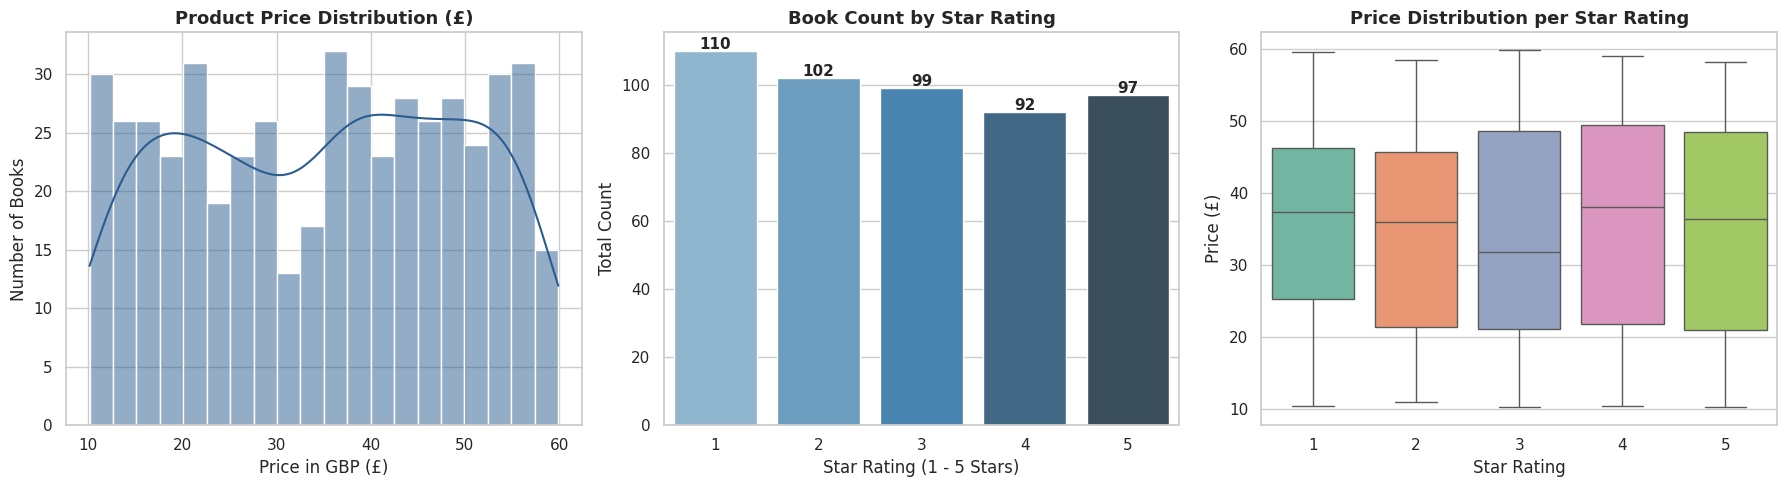


Visualizations successfully generated and saved as 'ecommerce_eda_visualizations.png'!


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Clean look ke liye visual style set karein
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

# Task 1 ki dataset load karein
df = pd.read_csv('scraped_ecommerce_products.csv')

# Charts ke liye layout banayein (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---------------------------------------------------------
# Chart 1: Price Distribution (Histogram + KDE)
# ---------------------------------------------------------
sns.histplot(df['Price_GBP'], kde=True, ax=axes[0], color='#2b5c8f', bins=20)
axes[0].set_title('Product Price Distribution (£)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Price in GBP (£)')
axes[0].set_ylabel('Number of Books')

# ---------------------------------------------------------
# Chart 2: Rating Distribution (Bar Chart)
# ---------------------------------------------------------
rating_counts = df['Star_Rating'].value_counts().sort_index().reset_index()
rating_counts.columns = ['Star_Rating', 'Count']

sns.barplot(data=rating_counts, x='Star_Rating', y='Count', ax=axes[1], palette='Blues_d')
axes[1].set_title('Book Count by Star Rating', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Star Rating (1 - 5 Stars)')
axes[1].set_ylabel('Total Count')

# Bars ke upar exact numbers display karein
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height())}",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5),
                    textcoords='offset points', fontweight='bold')

# ---------------------------------------------------------
# Chart 3: Price Spread across Ratings (Box Plot)
# ---------------------------------------------------------
sns.boxplot(data=df, x='Star_Rating', y='Price_GBP', ax=axes[2], palette='Set2')
axes[2].set_title('Price Distribution per Star Rating', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Star Rating')
axes[2].set_ylabel('Price (£)')

# Visuals clear karne ke liye adjust karein
plt.tight_layout()
plt.savefig('ecommerce_eda_visualizations.png', dpi=300) # High quality image save karega
plt.show()

print("\nVisualizations successfully generated and saved as 'ecommerce_eda_visualizations.png'!")